# HECO validation test v.2
---
## Climate condition analysis

this notebook is used to plot rosediagram and map for a characterization of climate condition at the location and date used for the validation test.
-> East mediterranean sea in the date 2021-07-23 to 2021-08-12, accordin to the study conducted about the oil spills that occurred at the Syrian Baniyas Station in the Eastern Mediterranean on August 23, 2021 (DOI: 10.1016/j.marpolbul.2023.115887).

In [1]:
import sys
print(sys.version)
import ipykernel
print(ipykernel.get_connection_file())

3.11.1 (v3.11.1:a7a450f84a, Dec  6 2022, 15:24:06) [Clang 13.0.0 (clang-1300.0.29.30)]
~/Library/Jupyter/runtime/kernel-v3fb43cb5fdb52177ce0b152476447e05acc32e217.json


In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import pandas as pd
import numpy as np
import os
import sys
import copernicusmarine
import windrose
import warnings
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import xarray as xr
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import ssl
import reportlab


In [3]:
from reportlab.lib.pagesizes import A4, inch
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.platypus import BaseDocTemplate, PageTemplate, Frame, Paragraph, Table, Image, PageBreak
from reportlab.platypus import Image as ResizeImage
from reportlab.lib.utils import ImageReader
from io import BytesIO


# 1. EU CMSES Datset access

Mediterranean Sea Physics Reanalysis
> Currents, hourly

`med-cmcc-cur-rean-h`

<details><summary> The Med MFC physical multiyear product is generated bya numerical system composed of an hydrodynamic model, supplied by the Nucleous for European Modelling of the Ocean (NEMO) and a variational data assimilation scheme (OceanVAR) for temperature and salinity vertical profiles and satellite Sea Level Anomaly along track data.  </summary> It contains a reanalysis dataset and an interim dataset which covers the period after the reanalysis until 1 month before present. The model horizontal grid resolution is 1/24˚ (ca. 4-5 km) and the unevenly spaced vertical levels are 141.

DOI (Product): https://doi.org/10.25423/CMCC/MEDSEA_MULTIYEAR_PHY_006_004_E3R1

DOI (Interim dataset): https://doi.org/10.25423/CMCC/MEDSEA_MULTIYEAR_PHY_006_004_E3R1I

References:

- Escudier, R., Clementi, E., Omar, M., Cipollone, A., Pistoia, J., Aydogdu, A., Drudi, M., Grandi, A., Lyubartsev, V., Lecci, R., Cretí, S., Masina, S., Coppini, G., & Pinardi, N. (2020). Mediterranean Sea Physical Reanalysis (CMEMS MED-Currents) (Version 1) [Data set]. Copernicus Monitoring Environment Marine Service (CMEMS). https://doi.org/10.25423/CMCC/MEDSEA_MULTIYEAR_PHY_006_004_E3R1
- Escudier, R., Clementi, E., Cipollone, A., Pistoia, J., Drudi, M., Grandi, A., Lyubartsev, V., Lecci, R., Aydogdu, A., Delrosso, D., Omar, M., Masina, S., Coppini G., Pinardi, N. (2021). A High Resolution Reanalysis for the Mediterranean Sea. Frontiers in Earth Science, 9, 1060, https://www.frontiersin.org/article/10.3389/feart.2021.702285, DOI=10.3389/feart.2021.702285
- Nigam, T., Escudier, R., Pistoia, J., Aydogdu, A., Omar, M., Clementi, E., Cipollone, A., Drudi, M., Grandi, A., Mariani, A., Lyubartsev, V., Lecci, R., Cretí, S., Masina, S., Coppini, G., & Pinardi, N. (2021). Mediterranean Sea Physical Reanalysis INTERIM (CMEMS MED-Currents, E3R1i system) (Version 1) [Data set]. Copernicus Monitoring Environment Marine Service (CMEMS). https://doi.org/10.25423/CMCC/MEDSEA_MULTIYEAR_PHY_006_004_E3R1I
</details>


<div style="padding: 10px; border: 1px solid orange; background-color: #fff3cd; color: #856404; border-radius: 5px;">
  <strong>Use CMSES Credenzials</strong> For send an API call with copernicusmarine function is mandatory use the credential provided by marine.copernicus.eu
</div>
More info about `copernicusmarine` API --> [link](https://help.marine.copernicus.eu/en/articles/8287609-copernicus-marine-toolbox-api-open-a-dataset-or-read-a-dataframe-remotely)

In [4]:
## Local current forcing used for Test 2
from pathlib import Path

DATASET_PATH = Path("med-cmcc-cur-rean-h_1751886654126.nc")
DS = xr.open_dataset(DATASET_PATH)
DS


INFO - 2025-10-19T06:07:22Z - Dataset version was not specified, the latest one was selected: "202012"
INFO - 2025-10-19T06:07:22Z - Dataset part was not specified, the first one was selected: "default"
INFO - 2025-10-19T06:07:26Z - Service was not specified, the default one was selected: "arco-geo-series"
username:password:

In [5]:
DS

<xarray.Dataset>
Dimensions:    (time: 385, latitude: 51, longitude: 58)
Coordinates:
  * latitude   (latitude) float32 34.6 34.65 34.69 34.73 ... 36.6 36.65 36.69
  * longitude  (longitude) float32 33.71 33.75 33.79 33.83 ... 36.0 36.04 36.08
  * time       (time) datetime64[ns] 2021-08-25 ... 2021-09-10
Data variables:
    uo         (time, latitude, longitude) float32 ...
    vo         (time, latitude, longitude) float32 ...
Attributes:
    Conventions:    CF-1.0
    bulletin_date:  20200901
    bulletin_type:  reanalysis
    comment:        Please check in CMEMS catalogue the INFO section for prod...
    contact:        servicedesk.cmems@mercator-ocean.eu
    field_type:     hourly_mean_centered_at_time_field
    institution:    Centro Euro-Mediterraneo sui Cambiamenti Climatici - CMCC...
    references:     Please check in CMEMS catalogue the INFO section for prod...
    source:         MFS E3R1
    title:          Horizontal Surface Velocity (2D) - Hourly Mean

site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/var/folders/y3/31vwk74d2xv464bxpc17c_280000gn/T/ipykernel_5937/1225825501.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
site-packages/cartopy/mpl/style.py:76: UserWarning: facecol

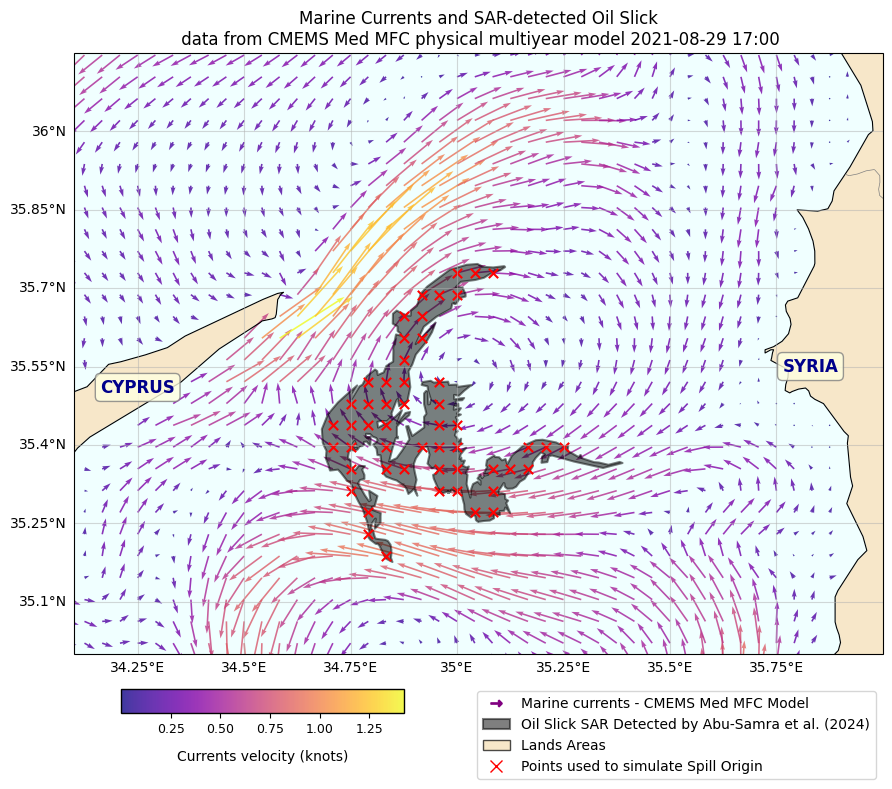

In [6]:
import matplotlib.pyplot as plt
import cartopy.io.img_tiles as cimgt
import cartopy.feature as cfeature
import geopandas as gpd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())


# find the nearest time step 
target_time = '2021-08-29T16:36'
ds_plot = DS.sel(time=target_time, method='nearest')
time_step = ds_plot.time


# vector colorbar with custom position outside the map, left-aligned 

# Plot vectors
# convert from m/s to knots
current_uo = ds_plot.uo.values * 1.94384
current_vo = ds_plot.vo.values * 1.94384

magnitude = np.sqrt(current_uo**2 + current_vo**2)
quiver = ax.quiver(
    ds_plot.longitude.values, 
    ds_plot.latitude.values,
    current_uo, 
    current_vo,
    magnitude,  #magnitude color value
    scale=15,
    width=0.002,
    cmap='plasma',  # 'plasma', 'inferno', 'turbo'
    alpha=0.8,
    transform=ccrs.PlateCarree()
)

# vector colorbar with custom position outside the map, left-aligned 
cax = inset_axes(ax, 
                width="35%",     
                height="4%",    
                loc='lower left', 
                bbox_to_anchor=(0.05, -0.11, 1, 1),  # (x, y, width, height)
                bbox_transform=ax.transAxes)
# draw white box on cax
cax.set_facecolor('white')
cax.set_alpha(1)

cbar = plt.colorbar(quiver, cax=cax, orientation='horizontal')

cbar.set_label('Currents velocity (knots)', rotation=0, labelpad=10, fontsize=10)
cbar.ax.tick_params(labelsize=9)
cbar.outline.set_linewidth(1)
cbar.outline.set_edgecolor('black')

cbar.fancybox = True
cbar.shadow = True


# add coastline
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, color='black')
#add land polygon
ax.add_feature(cfeature.LAND, color='wheat', alpha=0.7)




# country labels (manually located)
labels = {
    'CYPRUS': (34.25, 35.51),
    'SYRIA': (35.83, 35.55),
}

for country, (lon, lat) in labels.items():
    ax.text(lon, lat, country,
            transform=ccrs.PlateCarree(),
            fontsize=12, fontweight='bold', color='darkblue',
            ha='center', va='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8, edgecolor='gray'))


ax.add_feature(cfeature.OCEAN, color='azure')
ax.add_feature(cfeature.BORDERS, linewidth=0.5, color='gray')
# ax.add_feature(cfeature.LAKES, color='lightblue', alpha=0.7)
# ax.add_feature(cfeature.RIVERS, color='blue', linewidth=0.3)

# 
ax.set_title(f'Marine Currents and SAR-detected Oil Slick\n data from CMEMS Med MFC physical multiyear model {time_step.dt.strftime("%Y-%m-%d %H:%M").values}')
# ax.set_xlabel('Longitudine')
# ax.set_ylabel('Latitudine')
ax.set_xlim(34.1, 36.0)  # Longitudine
ax.set_ylim(35.0, 36.15)  # Latitudine
#Gridlines
gl = ax.gridlines(draw_labels=True, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Add GeoJson overlay
geojson_path = 'results/qgis_comparison/29-AUG-2021-AbouSamra-and-Ai-2024-oilspill-SAR-detection.geojson'
gdf = gpd.read_file(geojson_path)
gdf.plot(ax=ax, facecolor='black', edgecolor='black', alpha=0.5, linewidth=1.5, transform=ccrs.PlateCarree())

# add Virtual oil spill points
geojson_path2 = 'results/qgis_comparison/virtual_origin_oil_spill_points_2.geojson'
gdf2 = gpd.read_file(geojson_path2)
gdf2.plot(ax=ax, color='red', markersize=45, marker='x', transform=ccrs.PlateCarree(), label='Virtual Oil Spill Origin Points')
# ax.legend()
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='$\\rightarrow$', color='purple', label='Marine currents - CMEMS Med MFC Model',
           markerfacecolor='purple', markersize=8, linestyle='None'),
    Patch(facecolor='black', edgecolor='black', alpha=0.5, linewidth=1.5,
          label='Oil Slick SAR Detected by Abu-Samra et al. (2024)'),
    Patch(facecolor='wheat', edgecolor='black', alpha=0.7, label='Lands Areas'),
    Line2D([0], [0], marker='x', color='red', label='Points used to simulate Spill Origin',
           markerfacecolor='red', markersize=8, linestyle='None')
    #Line2D([0], [0], color='black', linewidth=0.8, label='Coastline')
]


# add legend
legend = ax.legend(handles=legend_elements, loc='upper right', 
          bbox_to_anchor=(1.0, -0.05), frameon=True, 
          fancybox=True, shadow=False, fontsize=10)

plt.tight_layout()
plt.savefig('results/validation_figure_0.png', dpi=300, bbox_inches='tight')
plt.show()

Log: convex hull polygons generated from HECO points results created
Log: querying HECO polygon 2021-08-29 16:36:07 in CMEMS dataset, found time step 2021-08-29 17:00
Saved figure: results/validation_figure_2021-08-29T16_36.png
Log: querying HECO polygon 2021-08-29 17:36:07 in CMEMS dataset, found time step 2021-08-29 18:00
Saved figure: results/validation_figure_2021-08-29T17_36.png
Log: querying HECO polygon 2021-08-29 18:36:07 in CMEMS dataset, found time step 2021-08-29 19:00
Saved figure: results/validation_figure_2021-08-29T18_36.png
Log: querying HECO polygon 2021-08-29 19:36:07 in CMEMS dataset, found time step 2021-08-29 20:00
Saved figure: results/validation_figure_2021-08-29T19_36.png
Log: querying HECO polygon 2021-08-29 20:36:07 in CMEMS dataset, found time step 2021-08-29 21:00
Saved figure: results/validation_figure_2021-08-29T20_36.png
Log: querying HECO polygon 2021-08-29 21:36:07 in CMEMS dataset, found time step 2021-08-29 22:00
Saved figure: results/validation_figur

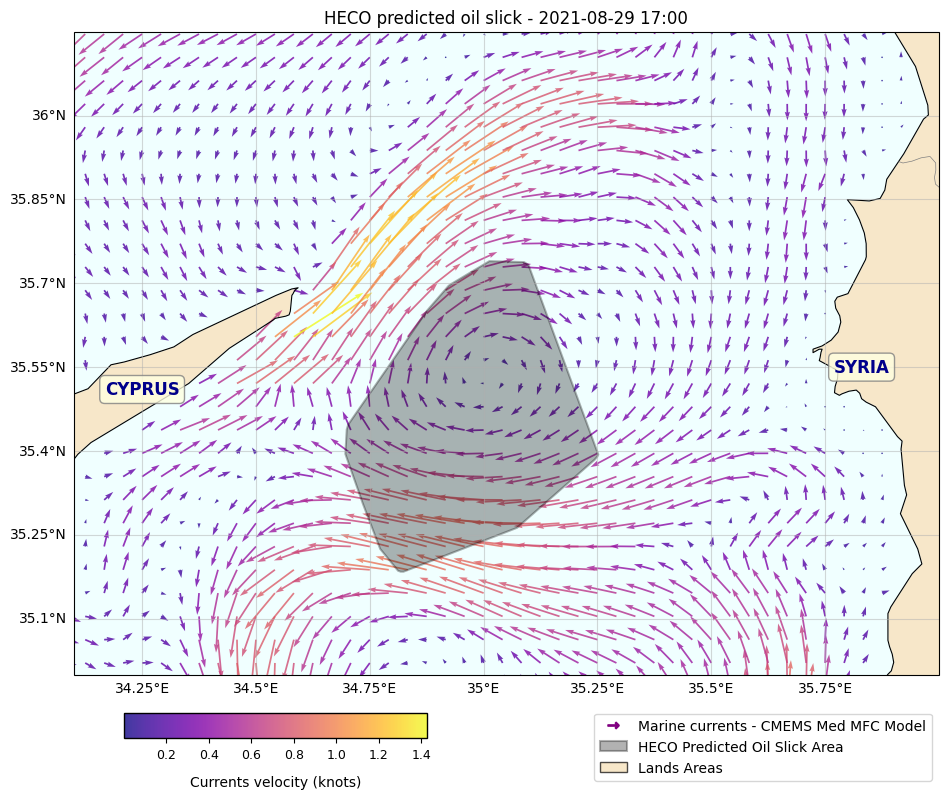

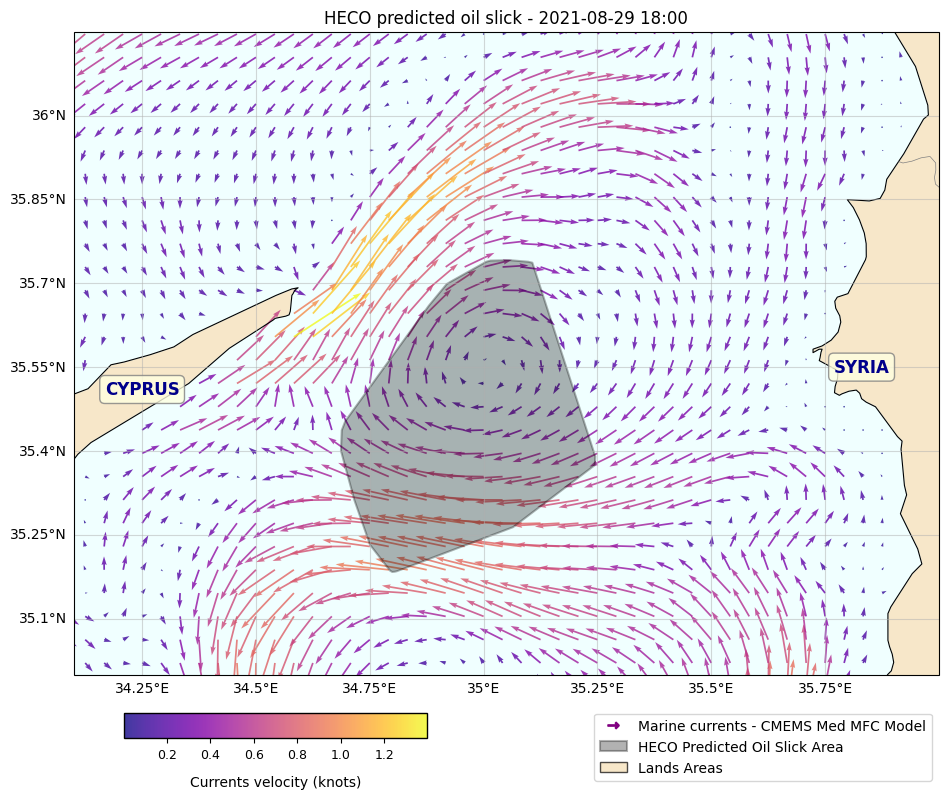

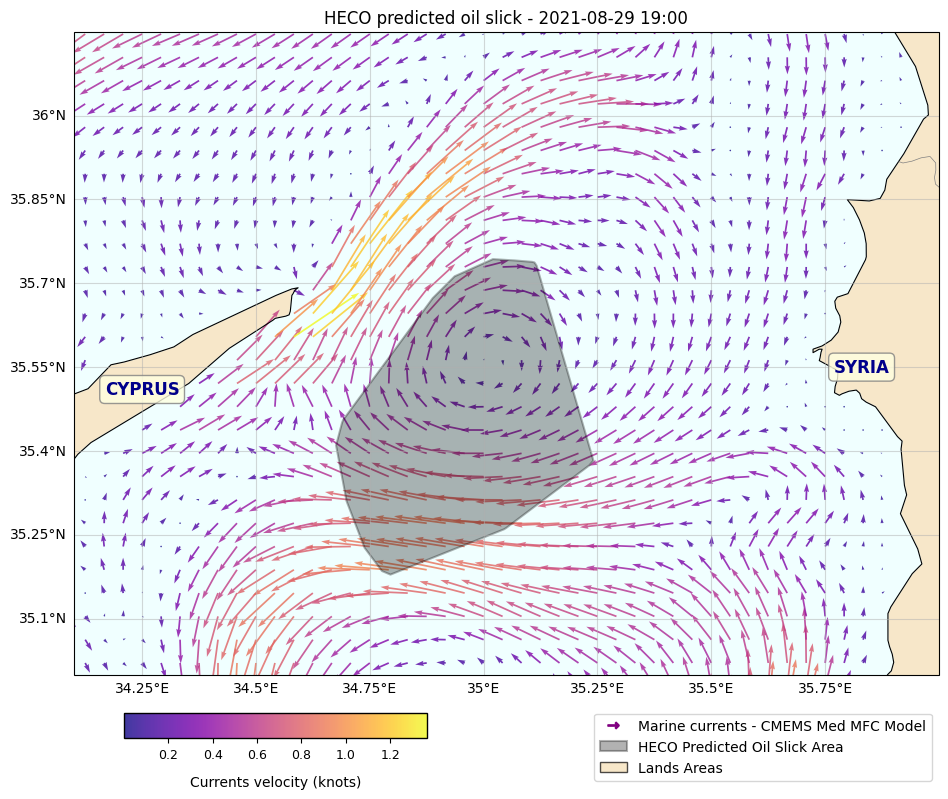

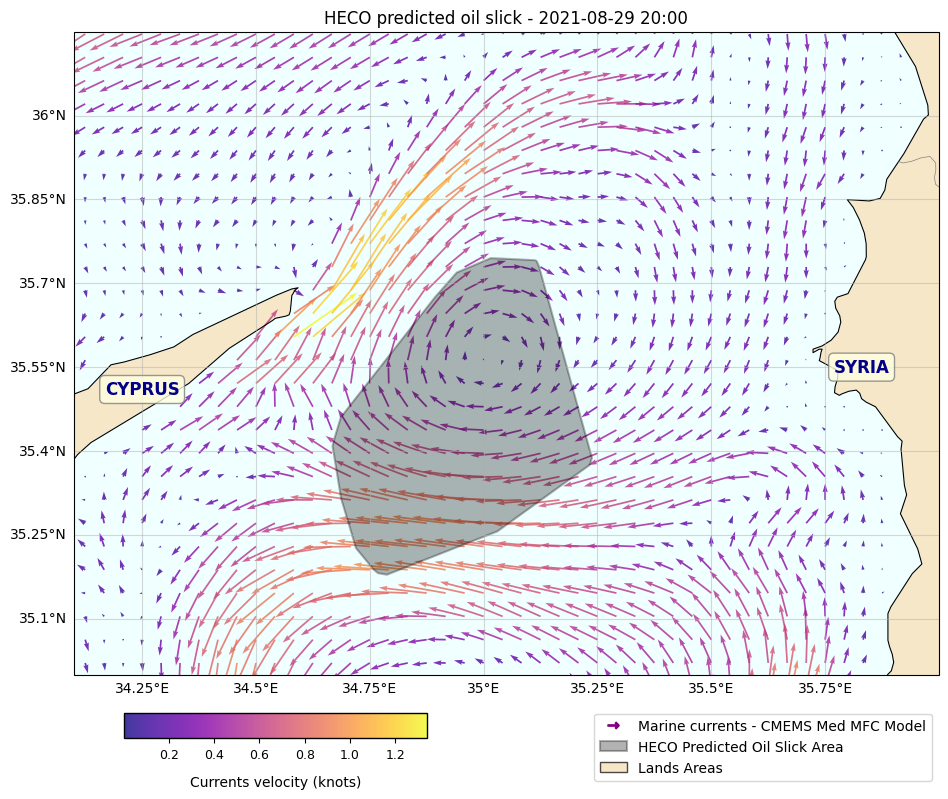

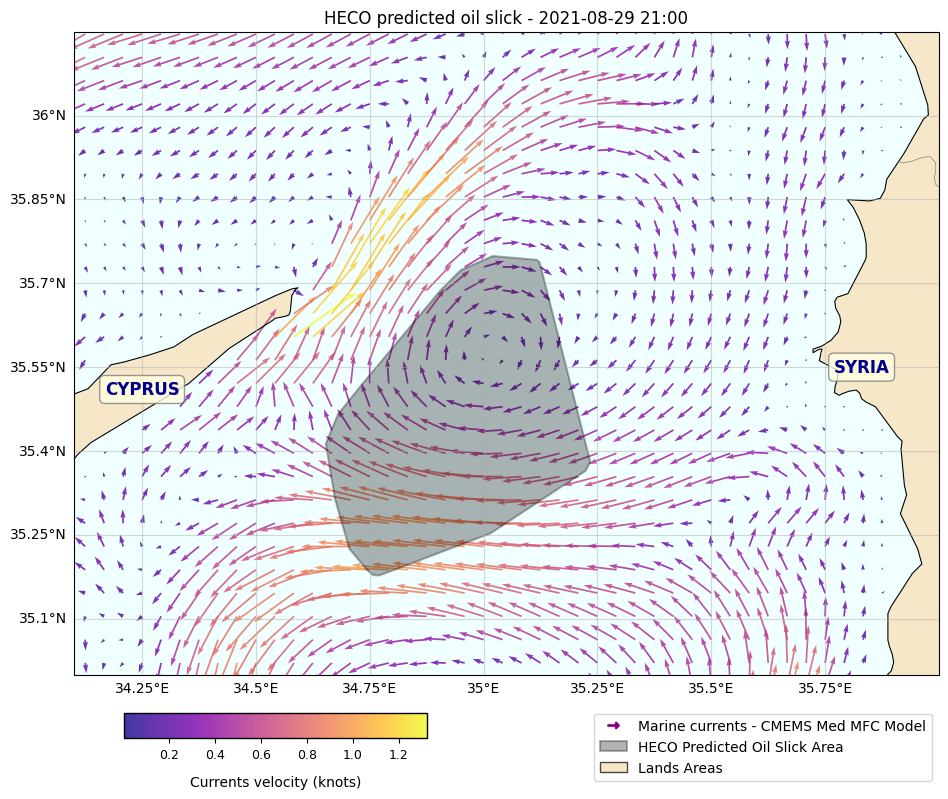

...

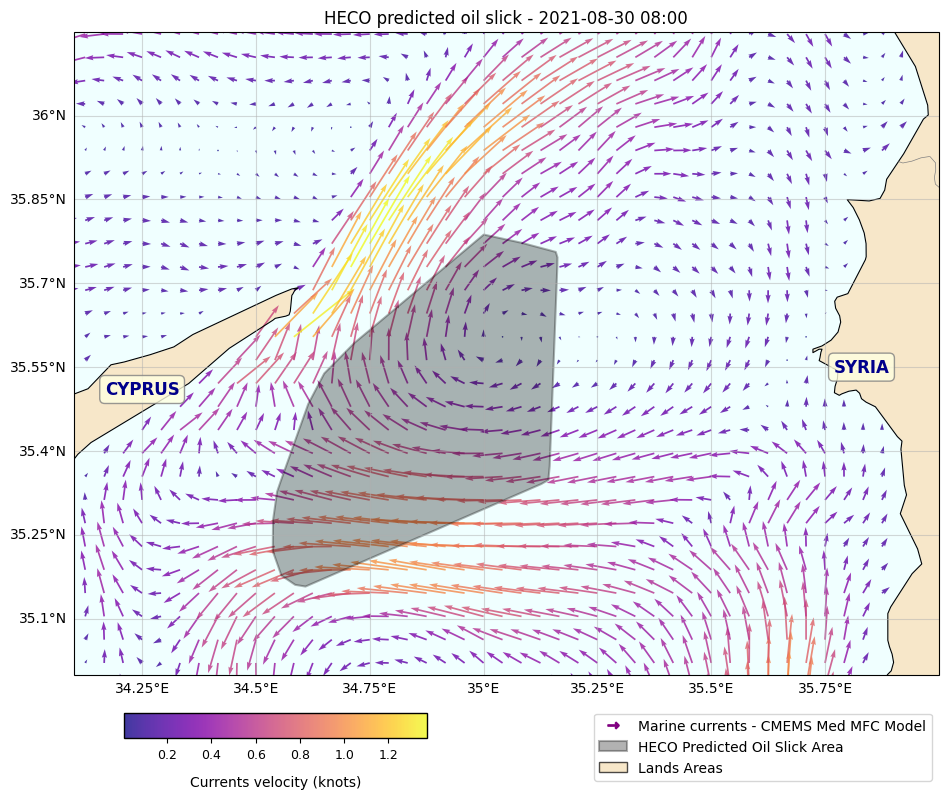

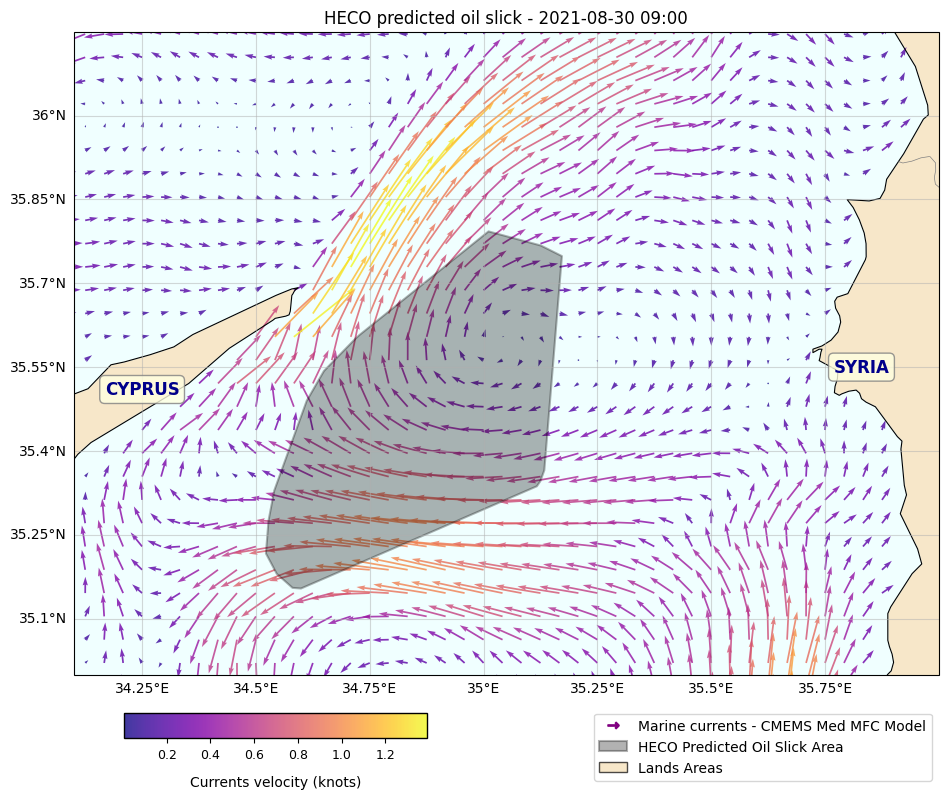

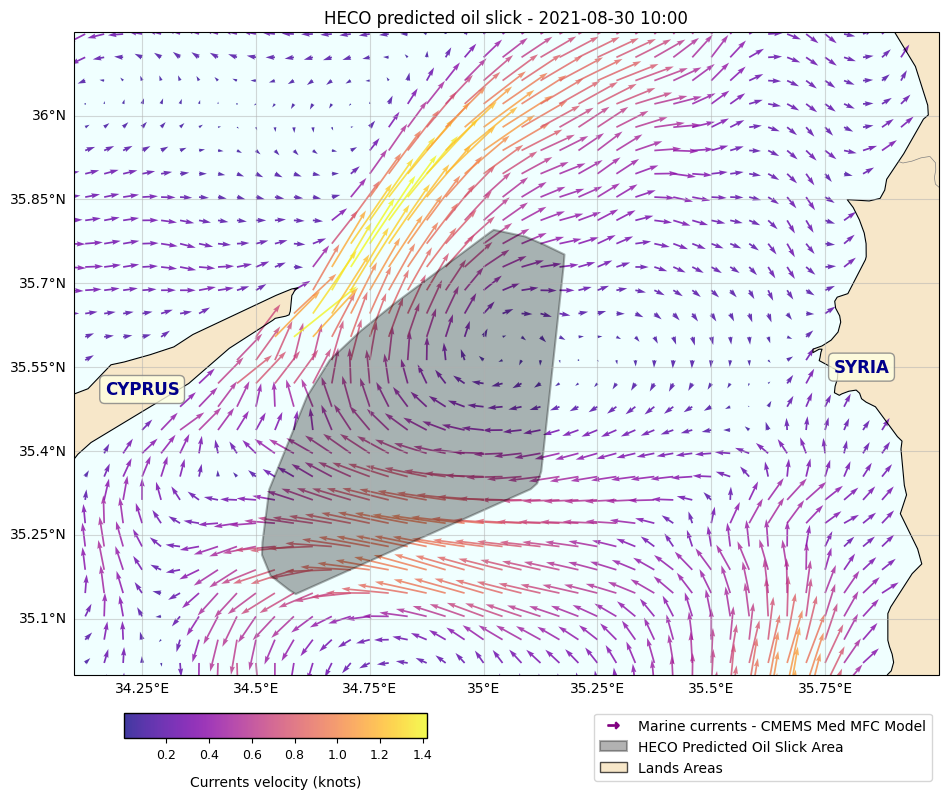

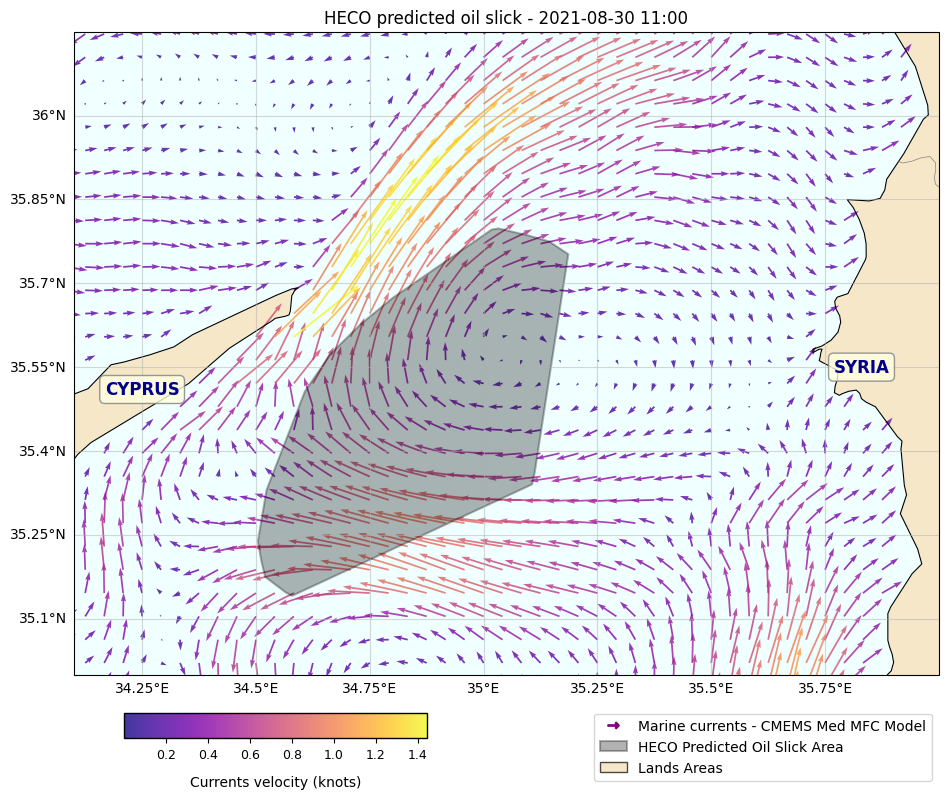

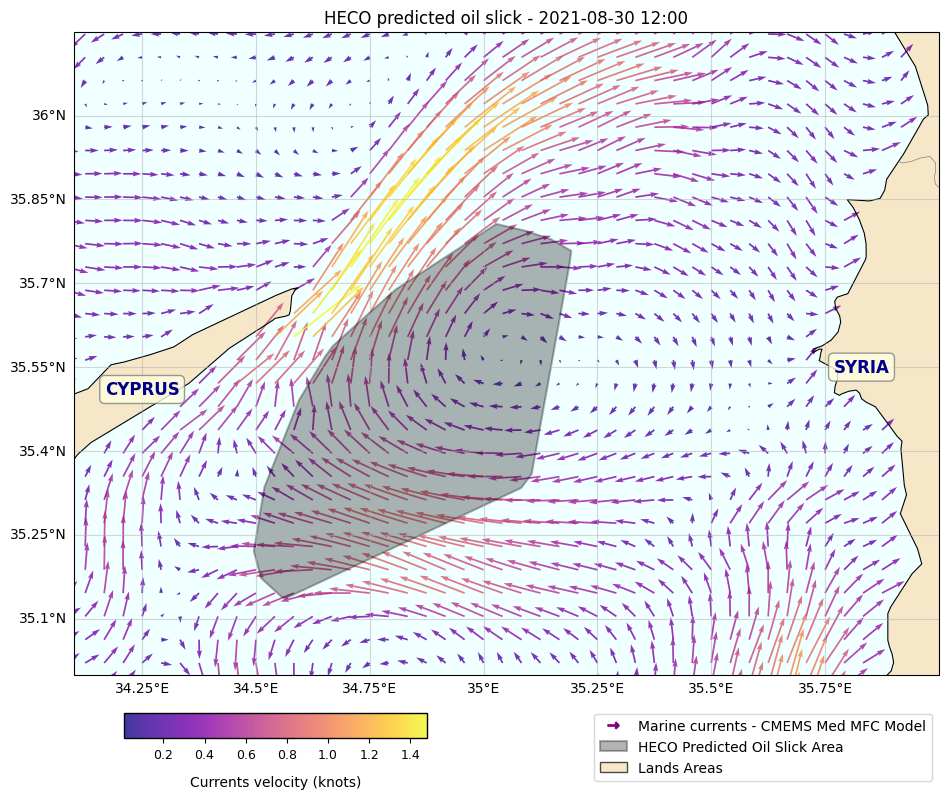

In [8]:
import matplotlib.pyplot as plt
import cartopy.io.img_tiles as cimgt
import cartopy.feature as cfeature
import geopandas as gpd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from heco import output_points_toconvexhull_polygons

#ignore warnings
import warnings
warnings.filterwarnings("ignore")

# load heco_points results from test 2
point_results_path = 'results/test2/heco-val-test2_results_global.geojson'
heco_points_results = gpd.read_file(point_results_path)
heco_polygons_results = output_points_toconvexhull_polygons(heco_points_results)
print('Log: convex hull polygons generated from HECO points results created')

for row in heco_polygons_results.items():
    # get polygon
    polygon_result = row
    timestampstring = polygon_result[0]
    # change time string from '2021-08-30 04:36:07' to '2021-08-30T04:36'
    target_time = timestampstring.replace(' ', 'T')[:-3] #ignore seconds due to the hourly data resolution
    # find the nearest time step in the DS data of CMEMS
    ds_plot = DS.sel(time=target_time, method='nearest')
    time_step = ds_plot.time
    print(f'Log: querying HECO polygon {timestampstring} in CMEMS dataset, found time step {time_step.dt.strftime("%Y-%m-%d %H:%M").values}')

    #load geometry
    geometry = polygon_result[1]

    # create  figure
    fig = plt.figure(figsize=(12, 8))
    # Create a Cartopy GeoAxes in the figure
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

    # Plot vectors
    # convert from m/s to knots
    current_uo = ds_plot.uo.values * 1.94384
    current_vo = ds_plot.vo.values * 1.94384

    # compute magnitude
    magnitude = np.sqrt(current_uo**2 + current_vo**2)

    # create quiver plot and add to ax
    quiver = ax.quiver(
        ds_plot.longitude.values, 
        ds_plot.latitude.values,
        current_uo, 
        current_vo,
        magnitude, 
        scale=15,
        width=0.002,
        cmap='plasma',  # 'plasma', 'inferno', 'turbo'
        alpha=0.8,
        transform=ccrs.PlateCarree()
    )

    # vector colorbar with custom position outside the map, left-aligned 
    cax = inset_axes(ax, 
                    width="35%",     
                    height="4%",    
                    loc='lower left', 
                    bbox_to_anchor=(0.05, -0.11, 1, 1),  # (x, y, width, height)
                    bbox_transform=ax.transAxes)
    
    # draw white box on cax
    cax.set_facecolor('white')
    cax.set_alpha(1)

    # add colorbar
    cbar = plt.colorbar(quiver, cax=cax, orientation='horizontal')
    cbar.set_label('Currents velocity (knots)', rotation=0, labelpad=10, fontsize=10)
    cbar.ax.tick_params(labelsize=9)
    cbar.outline.set_linewidth(1)
    cbar.outline.set_edgecolor('black')
    cbar.fancybox = True
    cbar.shadow = True


    # add coastline using cartopy
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, color='black')
    #add land polygon using cartopy
    ax.add_feature(cfeature.LAND, color='wheat', alpha=0.7)


    # country labels (manually located)
    labels = {
        'CYPRUS': (34.25, 35.51),
        'SYRIA': (35.83, 35.55),
    }

    for country, (lon, lat) in labels.items():
        ax.text(lon, lat, country,
                transform=ccrs.PlateCarree(),
                fontsize=12, fontweight='bold', color='darkblue',
                ha='center', va='center',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8, edgecolor='gray'))


    ax.add_feature(cfeature.OCEAN, color='azure')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, color='gray')

    # Title and limits
    ax.set_title(f'HECO predicted oil slick - {time_step.dt.strftime("%Y-%m-%d %H:%M").values}')
    ax.set_xlim(34.1, 36.0)  # Longitudine
    ax.set_ylim(35.0, 36.15)  # Latitudine

    # Gridlines
    gl = ax.gridlines(draw_labels=True, alpha=0.5)
    # remove top and right labels
    gl.top_labels = False
    gl.right_labels = False
        
    # plot HECO polygon
    gdf = gpd.GeoDataFrame(geometry=[geometry], crs="EPSG:4326")
    gdf.plot(ax=ax, facecolor='black', edgecolor='black', alpha=0.3, linewidth=1.5, transform=ccrs.PlateCarree())

    # add legend

    # create legend elements
    legend_elements = [
        Line2D([0], [0], marker='$\\rightarrow$', color='purple', label='Marine currents - CMEMS Med MFC Model',
            markerfacecolor='purple', markersize=8, linestyle='None'),
        Patch(facecolor='black', edgecolor='black', alpha=0.3, linewidth=1.5,
            label='HECO Predicted Oil Slick Area'),
        Patch(facecolor='wheat', edgecolor='black', alpha=0.7, label='Lands Areas')
        ]
    
    # add legend to ax
    legend = ax.legend(handles=legend_elements, loc='upper right', 
            bbox_to_anchor=(1.0, -0.05), frameon=True, 
            fancybox=True, shadow=False, fontsize=10)

    # adjust layout
    plt.tight_layout()

    # save figure
    filename = f'results/validation_figure_{target_time.replace(":", "_")}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f'Saved figure: {filename}')
    #plt.show()
